In [2]:
!pip install torch
!pip install torchvision

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 84.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 59.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 35.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 7.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 24.9 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 2.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 7.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 49.9 MB/s eta 0:00:0000:0100:01
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.

In [1]:
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader


from sklearn.model_selection import train_test_split

import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


<p style="color: purple; font-size: 30px; font-weight: bold; font-style: italic;">
Model Preprocessing 👇
</p>


In [7]:
dataset_path = "/kaggle/input/rice-image-dataset/Rice_Image_Dataset"

images = []
labels = []

for cls in os.listdir(dataset_path):
    cls_path = os.path.join(dataset_path, cls)
    if not os.path.isdir(cls_path):
        continue

    for img_name in os.listdir(cls_path):
        images.append(os.path.join(cls_path, img_name))
        labels.append(cls)

df = pd.DataFrame({
    'image': images,
    'label': labels
})


In [8]:
df['label_id'], uniques = pd.factorize(df['label'])
print("Class Names:", uniques.tolist())


Class Names: ['Karacadag', 'Basmati', 'Jasmine', 'Arborio', 'Ipsala']


In [9]:
# 80% Train + 20% Test
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df['label_id'],
    random_state=42
)

# Splitting 10% of the Total Dataset from the 80% Training Set for Validation
train_df, val_df = train_test_split(
    train_df,
    test_size=0.125,   # چون 0.8 * 0.125 = 0.1 → یعنی 10%
    stratify=train_df['label_id'],
    random_state=42
)

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))


Train: 52500
Validation: 7500
Test: 15000


In [10]:
df['label_id'], uniques = pd.factorize(df['label'])
print(uniques)


Index(['Karacadag', 'Basmati', 'Jasmine', 'Arborio', 'Ipsala'], dtype='object')


In [11]:
train_df.head()


,image,label,label_id
62203,/kaggle/input/rice-image-dataset/Rice_Image_Da...,Ipsala,4
38623,/kaggle/input/rice-image-dataset/Rice_Image_Da...,Jasmine,2
62791,/kaggle/input/rice-image-dataset/Rice_Image_Da...,Ipsala,4
7692,/kaggle/input/rice-image-dataset/Rice_Image_Da...,Karacadag,0
37077,/kaggle/input/rice-image-dataset/Rice_Image_Da...,Jasmine,2


In [12]:

transform = transforms.Compose([
    transforms.Resize((128,128)),   
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5), (0.5,0.5,0.5))
])


In [13]:

transform = transforms.Compose([
    transforms.Resize((128,128)),          
    transforms.ToTensor(),                   
    transforms.Normalize(             
        mean=(0.5, 0.5, 0.5),
        std=(0.5, 0.5, 0.5)
    )
])

In [14]:
from torch.utils.data import Dataset
from PIL import Image

class RiceDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.paths = dataframe['image'].values        
        self.labels = dataframe['label_id'].values    
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        
        img_path = self.paths[idx]
        img = Image.open(img_path).convert("RGB")

        
        label = int(self.labels[idx])

        
        if self.transform:
            img = self.transform(img)

        return img, label


In [15]:

batch_size = 32

train_dataset = RiceDataset(train_df, transform=transform)
val_dataset = RiceDataset(val_df, transform=transform)
test_dataset = RiceDataset(test_df, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(len(train_loader), len(val_loader), len(test_loader))


1641 235 469


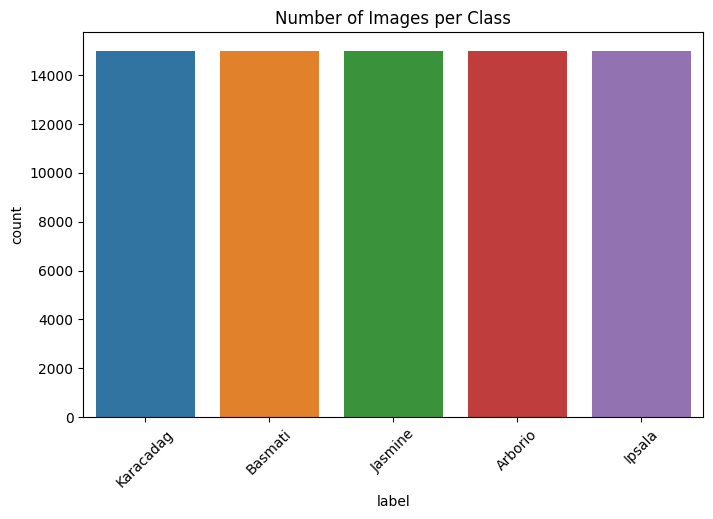

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.countplot(data=df, x="label")
plt.title("Number of Images per Class")
plt.xticks(rotation=45)
plt.show()


In [14]:
print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))


Train: 52500
Validation: 7500
Test: 15000


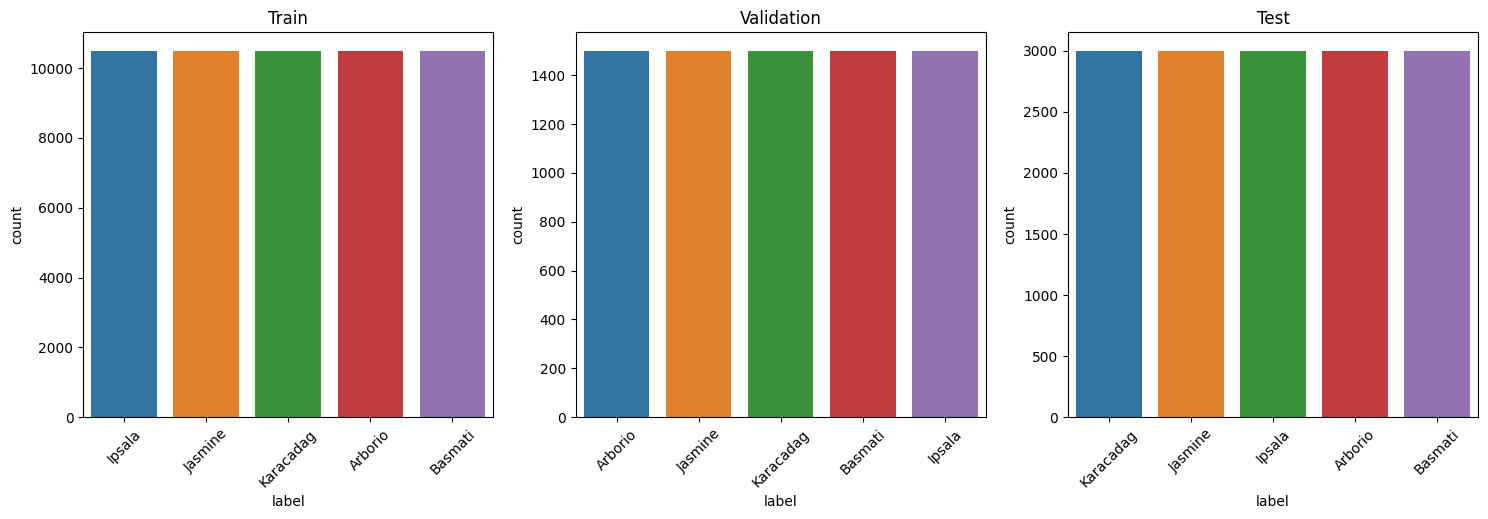

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))

sns.countplot(data=train_df, x='label', ax=axes[0])
axes[0].set_title("Train")

sns.countplot(data=val_df, x='label', ax=axes[1])
axes[1].set_title("Validation")

sns.countplot(data=test_df, x='label', ax=axes[2])
axes[2].set_title("Test")

plt.setp(axes, xticks=range(len(df['label'].unique())))
for ax in axes:
    ax.tick_params(axis='x', rotation=45)

plt.show()


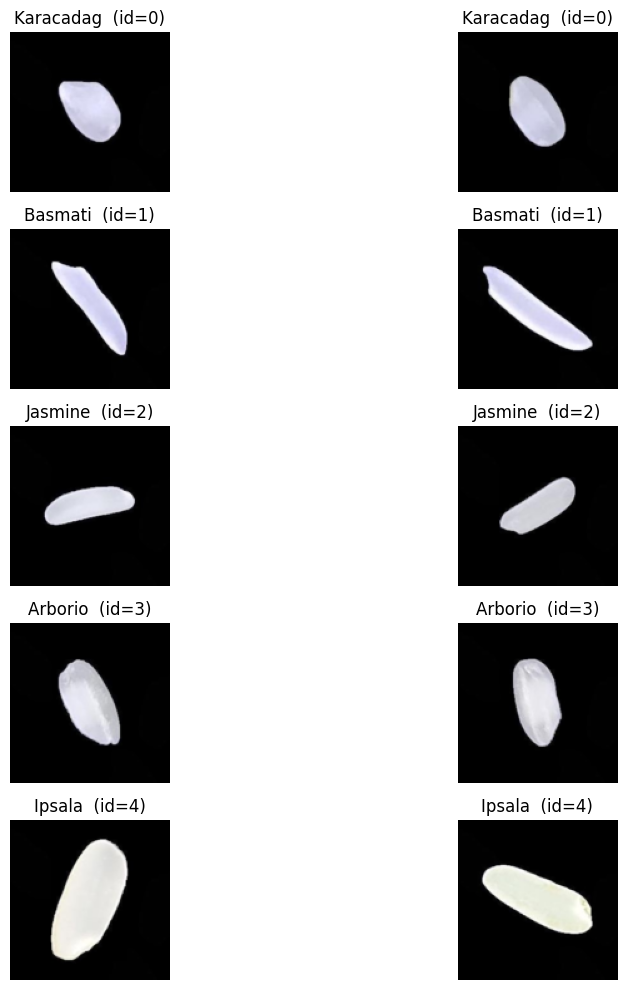

In [19]:
import numpy as np
def show_samples_per_class(dataset, class_names, samples_per_class=2):
    
# Dictionary for storing the samples
    collected = {cls: [] for cls in range(len(class_names))}

# Iterate through the dataset until enough samples are found
    for img, label in dataset:
        if len(collected[label]) < samples_per_class:
            collected[label].append(img)
        
# Stop when enough samples have been collected from all classes
            if all(len(collected[c]) == samples_per_class for c in collected):
            break
    
    total = samples_per_class * len(class_names)
    plt.figure(figsize=(12, total))

    index = 1
    for label_id in range(len(class_names)):
        for img in collected[label_id]:
            img_np = img.permute(1, 2, 0).numpy()
            img_np = (img_np * 0.5) + 0.5      # denormalize
            img_np = np.clip(img_np, 0, 1)

            plt.subplot(len(class_names), samples_per_class, index)
            plt.imshow(img_np)
            plt.title(f"{class_names[label_id]}  (id={label_id})")
            plt.axis("off")
            index += 1

    plt.tight_layout()
    plt.show()


show_samples_per_class(train_dataset, uniques, samples_per_class=2)


In [20]:
sample, label = train_dataset[0]
print("Image shape:", sample.shape)
print("Label:", label)


Image shape: torch.Size([3, 128, 128])
Label: 4


In [21]:
print("Class names found in dataset:", uniques)
print("Number of images per class:")
print(df['label'].value_counts())


Class names found in dataset: Index(['Karacadag', 'Basmati', 'Jasmine', 'Arborio', 'Ipsala'], dtype='object')
Number of images per class:
label
Karacadag    15000
Basmati      15000
Jasmine      15000
Arborio      15000
Ipsala       15000
Name: count, dtype: int64


<p style="color: purple; font-size: 30px; font-weight: bold; font-style: italic;">
Simple Model Construction 👇
</p>


In [23]:
import torch.nn as nn
import torch.nn.functional as F

class TinyCNN(nn.Module):
    def __init__(self, num_classes=5):
        super(TinyCNN, self).__init__()
        
        # 1) Convolution
        self.conv = nn.Conv2d(in_channels=3, out_channels=8, kernel_size=3, padding=1)
        
        # 2) MaxPooling
        self.pool = nn.MaxPool2d(2, 2)

# If the input is 128x128:
# After pooling → the size becomes 64x64 with 8 channels
    self.fc = nn.Linear(8 * 64 * 64, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.conv(x)))  # Conv → ReLU → Pool
        x = x.view(x.size(0), -1)            # Flatten
        x = self.fc(x)                       # Fully connected
        return x


In [20]:
model = TinyCNN(num_classes=5)
print(model)


TinyCNN(
  (conv): Conv2d(3, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc): Linear(in_features=32768, out_features=5, bias=True)
)


In [21]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)


In [27]:
# Lists for storing values
train_losses, val_losses = [], []
train_accs, val_accs = [], []

def train(model, train_loader, val_loader, epochs=10, device="cpu"):
    model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    for epoch in range(epochs):
        # ------------------ TRAIN ------------------
        model.train()
        train_loss = 0
        train_acc = 0

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            train_acc += accuracy_fn(outputs, labels)

        train_loss /= len(train_loader)
        train_acc /= len(train_loader)

        # ------------------ VALIDATION ------------------
        model.eval()
        val_loss = 0
        val_acc = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)
                labels = labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                val_acc += accuracy_fn(outputs, labels)

        val_loss /= len(val_loader)
        val_acc /= len(val_loader)

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)

        print(f"Epoch {epoch+1}/{epochs} | "
              f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc*100:.2f}% | "
              f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc*100:.2f}%")

    return train_losses, val_losses, train_accs, val_accs


In [28]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

train_losses, val_losses, train_accs, val_accs = train(model, train_loader, val_loader, epochs=10, device=device)


Epoch 1/10 | Train Loss: 0.0111 | Train Acc: 99.64% | Val Loss: 0.0273 | Val Acc: 99.24%
Epoch 2/10 | Train Loss: 0.0078 | Train Acc: 99.73% | Val Loss: 0.0228 | Val Acc: 99.23%
Epoch 3/10 | Train Loss: 0.0074 | Train Acc: 99.76% | Val Loss: 0.0129 | Val Acc: 99.49%
Epoch 4/10 | Train Loss: 0.0079 | Train Acc: 99.74% | Val Loss: 0.0415 | Val Acc: 99.15%
Epoch 5/10 | Train Loss: 0.0069 | Train Acc: 99.77% | Val Loss: 0.0163 | Val Acc: 99.53%
Epoch 6/10 | Train Loss: 0.0037 | Train Acc: 99.89% | Val Loss: 0.0135 | Val Acc: 99.60%
Epoch 7/10 | Train Loss: 0.0054 | Train Acc: 99.79% | Val Loss: 0.0145 | Val Acc: 99.60%
Epoch 8/10 | Train Loss: 0.0059 | Train Acc: 99.78% | Val Loss: 0.0298 | Val Acc: 99.32%
Epoch 9/10 | Train Loss: 0.0038 | Train Acc: 99.88% | Val Loss: 0.0184 | Val Acc: 99.41%
Epoch 10/10 | Train Loss: 0.0048 | Train Acc: 99.82% | Val Loss: 0.0143 | Val Acc: 99.52%


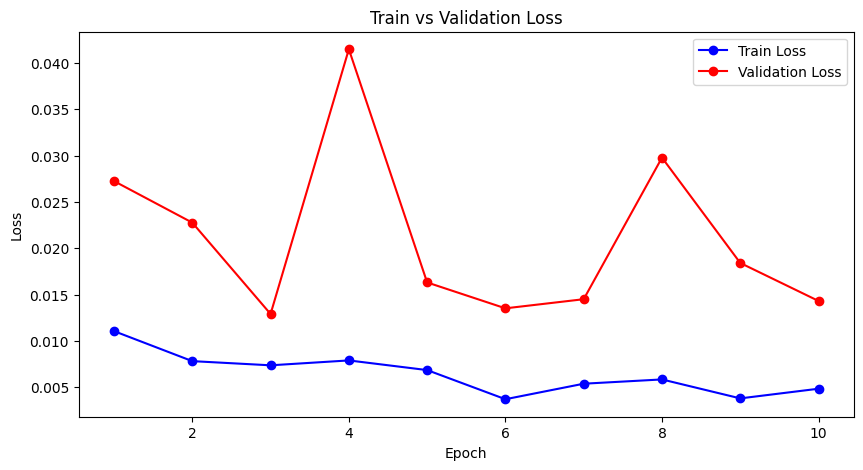

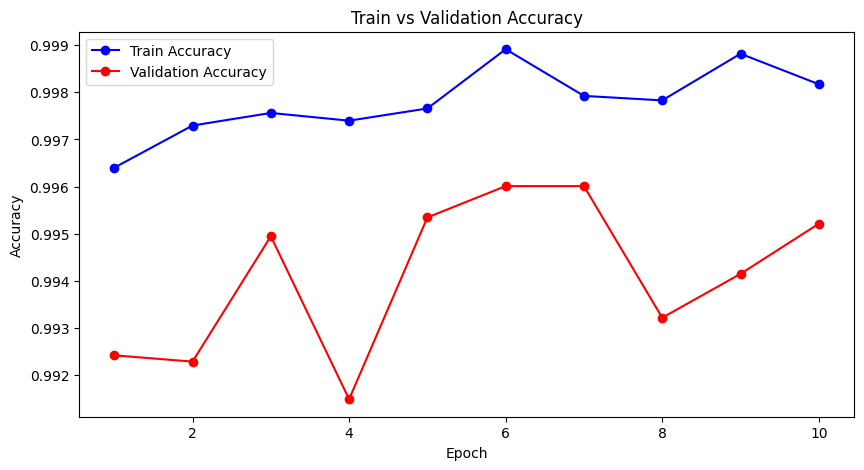

In [29]:
import matplotlib.pyplot as plt
epochs = range(1, 11)

# Loss
plt.figure(figsize=(10,5))
plt.plot(epochs, train_losses, 'b-o', label='Train Loss')
plt.plot(epochs, val_losses, 'r-o', label='Validation Loss')
plt.title('Train vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Accuracy
plt.figure(figsize=(10,5))
plt.plot(epochs, train_accs, 'b-o', label='Train Accuracy')
plt.plot(epochs, val_accs, 'r-o', label='Validation Accuracy')
plt.title('Train vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()



<p style="color: purple; font-size: 30px; font-weight: bold; font-style: italic;">
The fluctuation increased; the model needs to be more complex 👇
</p>



In [24]:

class SimpleCNN(nn.Module):
    def __init__(self, num_classes=5):
        super(SimpleCNN, self).__init__()
        
# 1. Simple convolution
        self.conv = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.bn = nn.BatchNorm2d(16)  # نرمال سازی کانال‌ها
        
        # 2 Pooling
        self.pool = nn.MaxPool2d(2, 2)
        
# Dropout before the fully connected layer
        self.dropout = nn.Dropout(0.3)
        
        # Fully connected
# Input: after two pooling layers on 128x128 → 16 * 32 * 32
    self.fc = nn.Linear(16*32*32, num_classes)
        
    def forward(self, x):
        x = F.relu(self.bn(self.conv(x)))
        x = self.pool(x)
        x = self.pool(x)   # Pool دوم
        x = x.view(x.size(0), -1)
        x = self.dropout(x)
        x = self.fc(x)
        return x

model = SimpleCNN(num_classes=5)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)


SimpleCNN(
  (conv): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=16384, out_features=5, bias=True)
)

In [25]:
import torch.optim as optim
import matplotlib.pyplot as plt

def accuracy_fn(preds, labels):
    predicted = torch.argmax(preds, dim=1)
    return (predicted == labels).float().mean().item()

def train_and_track(model, train_loader, val_loader, epochs=10, device="cpu"):
    model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    
# Lists for storing loss and accuracy
    train_losses, val_losses = [], []
    train_accs, val_accs = [], []

    for epoch in range(epochs):
        # ------------------ TRAIN ------------------
        model.train()
        train_loss = 0
        train_acc = 0

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            train_acc += accuracy_fn(outputs, labels)

        train_loss /= len(train_loader)
        train_acc /= len(train_loader)

        # ------------------ VALIDATION ------------------
        model.eval()
        val_loss = 0
        val_acc = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item()
                val_acc += accuracy_fn(outputs, labels)

        val_loss /= len(val_loader)
        val_acc /= len(val_loader)

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)

        print(f"Epoch {epoch+1}/{epochs} | "
              f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc*100:.2f}% | "
              f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc*100:.2f}%")
    
    return train_losses, val_losses, train_accs, val_accs


In [33]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

train_losses, val_losses, train_accs, val_accs = train_and_track(
    model, train_loader, val_loader, epochs=10, device=device
)


Epoch 1/10 | Train Loss: 0.1547 | Train Acc: 95.42% | Val Loss: 0.0742 | Val Acc: 98.01%
Epoch 2/10 | Train Loss: 0.0788 | Train Acc: 97.83% | Val Loss: 0.0360 | Val Acc: 98.98%
Epoch 3/10 | Train Loss: 0.0673 | Train Acc: 98.17% | Val Loss: 0.0260 | Val Acc: 99.12%
Epoch 4/10 | Train Loss: 0.0547 | Train Acc: 98.42% | Val Loss: 0.0268 | Val Acc: 99.32%
Epoch 5/10 | Train Loss: 0.0466 | Train Acc: 98.65% | Val Loss: 0.0134 | Val Acc: 99.52%
Epoch 6/10 | Train Loss: 0.0412 | Train Acc: 98.80% | Val Loss: 0.0151 | Val Acc: 99.51%
Epoch 7/10 | Train Loss: 0.0363 | Train Acc: 98.89% | Val Loss: 0.0109 | Val Acc: 99.60%
Epoch 8/10 | Train Loss: 0.0291 | Train Acc: 99.08% | Val Loss: 0.0193 | Val Acc: 99.31%
Epoch 9/10 | Train Loss: 0.0274 | Train Acc: 99.13% | Val Loss: 0.0415 | Val Acc: 98.47%
Epoch 10/10 | Train Loss: 0.0242 | Train Acc: 99.25% | Val Loss: 0.0141 | Val Acc: 99.59%


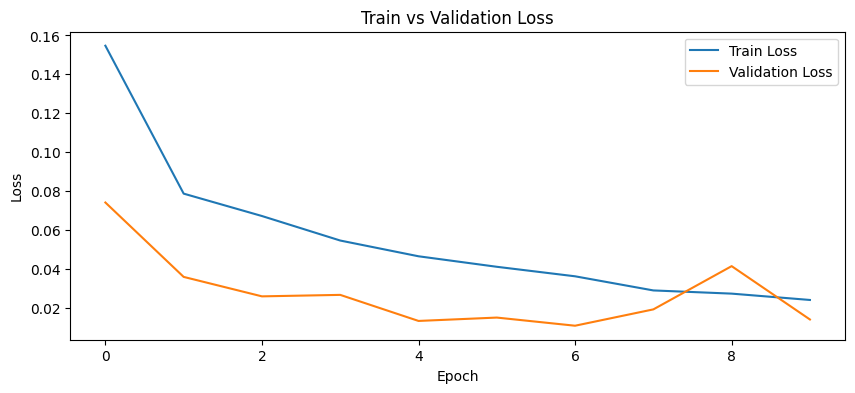

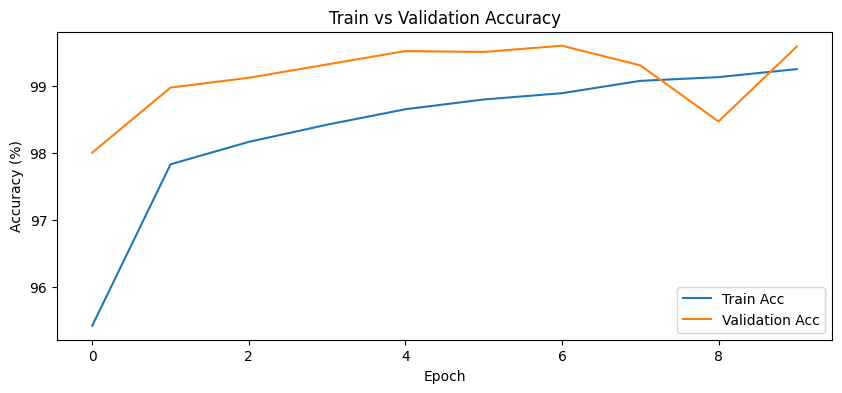

In [34]:

plt.figure(figsize=(10,4))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train vs Validation Loss")
plt.legend()
plt.show()

plt.figure(figsize=(10,4))
plt.plot([x*100 for x in train_accs], label="Train Acc")
plt.plot([x*100 for x in val_accs], label="Validation Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Train vs Validation Accuracy")
plt.legend()
plt.show()


<p style="color: blue; font-size: 20px; font-weight: bold; font-style: italic;">
The number of model epochs should be increased to see where the fluctuation decreases 👇
</p>


In [26]:
# Reinitialize from scratch
model = SimpleCNN(num_classes=5)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Run with more epochs, e.g., 20
train_losses, val_losses, train_accs, val_accs = train_and_track(
    model, train_loader, val_loader, epochs=20, device=device
)


Epoch 1/20 | Train Loss: 0.1578 | Train Acc: 95.34% | Val Loss: 0.0862 | Val Acc: 97.61%
Epoch 2/20 | Train Loss: 0.0948 | Train Acc: 97.53% | Val Loss: 0.4079 | Val Acc: 88.74%
Epoch 3/20 | Train Loss: 0.0670 | Train Acc: 98.10% | Val Loss: 0.0386 | Val Acc: 98.99%
Epoch 4/20 | Train Loss: 0.0566 | Train Acc: 98.39% | Val Loss: 0.0247 | Val Acc: 99.23%
Epoch 5/20 | Train Loss: 0.0487 | Train Acc: 98.60% | Val Loss: 0.2502 | Val Acc: 93.47%
Epoch 6/20 | Train Loss: 0.0477 | Train Acc: 98.53% | Val Loss: 0.0220 | Val Acc: 99.31%
Epoch 7/20 | Train Loss: 0.0416 | Train Acc: 98.75% | Val Loss: 0.0270 | Val Acc: 99.14%
Epoch 8/20 | Train Loss: 0.0330 | Train Acc: 98.94% | Val Loss: 0.0306 | Val Acc: 99.11%
Epoch 9/20 | Train Loss: 0.0298 | Train Acc: 99.00% | Val Loss: 0.0171 | Val Acc: 99.39%
Epoch 10/20 | Train Loss: 0.0249 | Train Acc: 99.20% | Val Loss: 0.0116 | Val Acc: 99.59%
Epoch 11/20 | Train Loss: 0.0231 | Train Acc: 99.22% | Val Loss: 0.0445 | Val Acc: 98.62%
Epoch 12/20 | Train

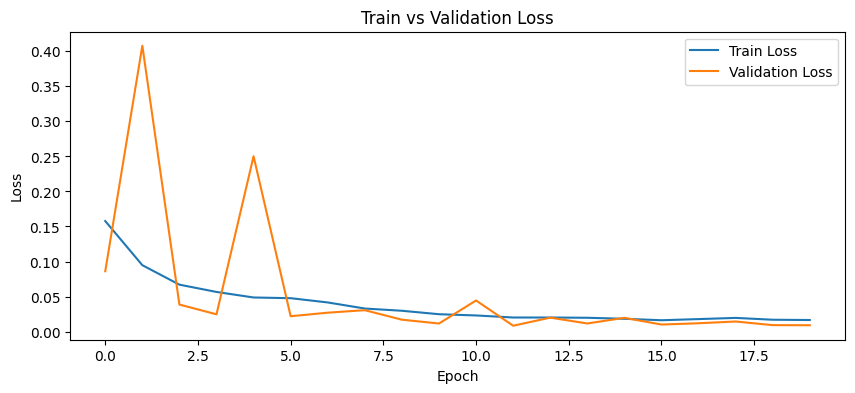

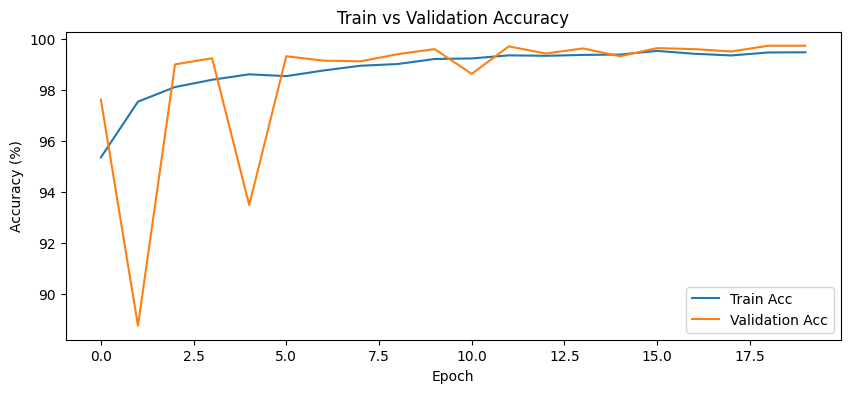

In [27]:

# Plot the Loss curve
plt.figure(figsize=(10,4))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train vs Validation Loss")
plt.legend()
plt.show()

# Plot the Accuracy curve
plt.figure(figsize=(10,4))
plt.plot([x*100 for x in train_accs], label="Train Acc")
plt.plot([x*100 for x in val_accs], label="Validation Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Train vs Validation Accuracy")
plt.legend()
plt.show()



<p style="color: purple; font-size: 30px; font-weight: bold; font-style: italic;">
The model has almost stabilized from epoch 13, is not overfitted, and has learned excellently 
</p>


In [29]:
torch.save(model, "rice_cnn_model.pth")

,Epoch,Train Loss,Train Acc (%),Val Loss,Val Acc (%)
0,1,0.157800,95.340000,0.086200,97.610000
1,2,0.094800,97.530000,0.407900,88.740000
2,3,0.067000,98.100000,0.038600,98.990000
3,4,0.056600,98.390000,0.024700,99.230000
4,5,0.048700,98.600000,0.250200,93.470000
5,6,0.047700,98.530000,0.022000,99.310000
6,7,0.041600,98.750000,0.027000,99.140000
7,8,0.033000,98.940000,0.030600,99.110000
8,9,0.029800,99.000000,0.017100,99.390000
9,10,0.024900,99.200000,0.011600,99.590000


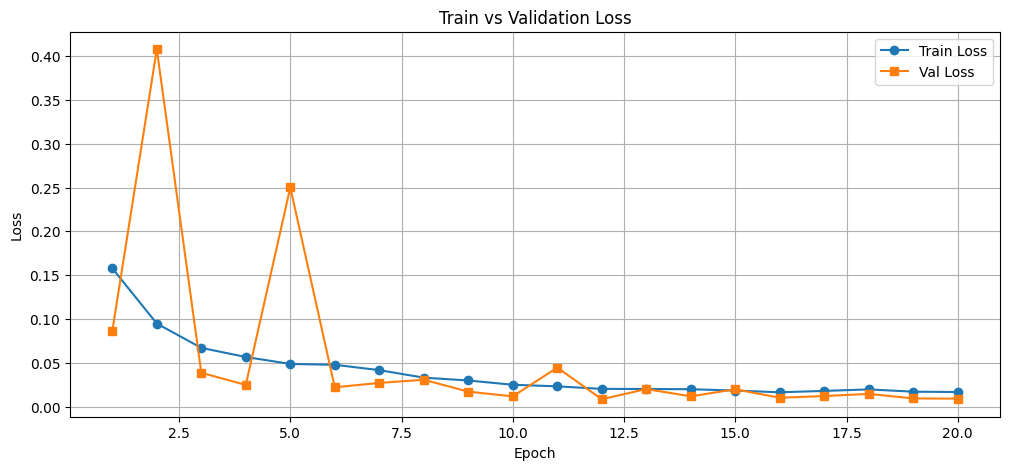

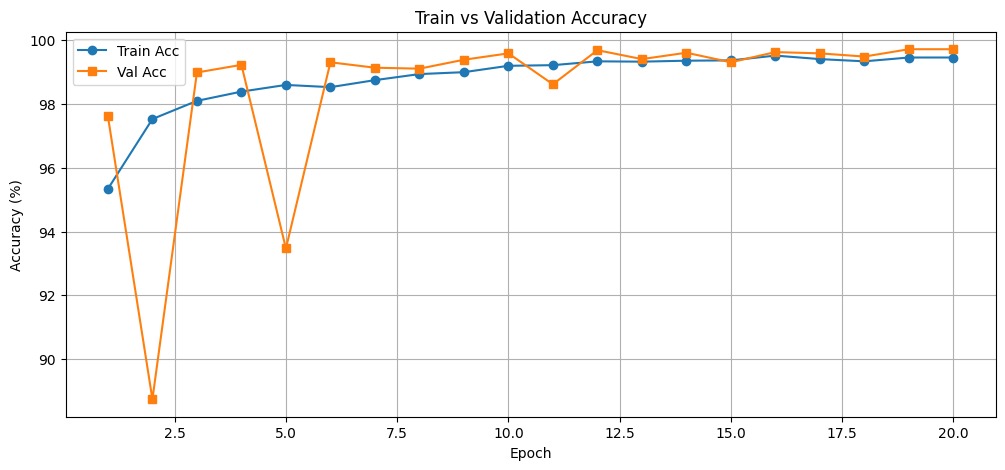

In [31]:
import matplotlib.pyplot as plt
import pandas as pd

history = {
    "Epoch": list(range(1, 21)),
    "Train Loss": [0.1578,0.0948,0.0670,0.0566,0.0487,0.0477,0.0416,0.0330,0.0298,0.0249,
                   0.0231,0.0202,0.0201,0.0198,0.0183,0.0163,0.0179,0.0196,0.0170,0.0166],
    "Train Acc (%)": [95.34,97.53,98.10,98.39,98.60,98.53,98.75,98.94,99.00,99.20,
                      99.22,99.34,99.33,99.36,99.37,99.52,99.41,99.34,99.46,99.46],
    "Val Loss": [0.0862,0.4079,0.0386,0.0247,0.2502,0.0220,0.0270,0.0306,0.0171,0.0116,
                 0.0445,0.0084,0.0200,0.0117,0.0197,0.0101,0.0120,0.0145,0.0093,0.0091],
    "Val Acc (%)": [97.61,88.74,98.99,99.23,93.47,99.31,99.14,99.11,99.39,99.59,
                    98.62,99.69,99.41,99.61,99.31,99.63,99.59,99.49,99.72,99.72]
}

df_history = pd.DataFrame(history)

styled_table = df_history.style.background_gradient(cmap='YlGnBu', subset=["Train Loss", "Val Loss"]) \
                                .background_gradient(cmap='YlOrRd', subset=["Train Acc (%)", "Val Acc (%)"]) \
                                .set_properties(**{'font-size': '12pt', 'text-align': 'center'}) \
                                .set_table_styles([dict(selector='th', props=[('font-size', '12pt')])])

display(styled_table)

# ----------------  Loss chart  ----------------
plt.figure(figsize=(12,5))
plt.plot(df_history["Epoch"], df_history["Train Loss"], label="Train Loss", marker='o')
plt.plot(df_history["Epoch"], df_history["Val Loss"], label="Val Loss", marker='s')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

# ----------------  Accuracy chart ----------------
plt.figure(figsize=(12,5))
plt.plot(df_history["Epoch"], df_history["Train Acc (%)"], label="Train Acc", marker='o')
plt.plot(df_history["Epoch"], df_history["Val Acc (%)"], label="Val Acc", marker='s')
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Train vs Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()



<p style="color: purple; font-size: 30px; font-weight: bold; font-style: italic;">
Evaluating the test data on the final model 👇
</p>


In [32]:
# ---------------- Evaluation function on the test data ----------------
def test_model(model, test_loader, device="cpu"):
    model.eval()
    model.to(device)
    criterion = nn.CrossEntropyLoss()

    test_loss = 0
    test_acc = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            test_loss += loss.item()
            test_acc += (torch.argmax(outputs, dim=1) == labels).float().mean().item()

    test_loss /= len(test_loader)
    test_acc /= len(test_loader)

    print(f"Test Loss: {test_loss:.4f} | Test Accuracy: {test_acc*100:.2f}%")
    return test_loss, test_acc

# ---------------- Run evaluation ----------------
test_loss, test_acc = test_model(model, test_loader, device=device)


Test Loss: 0.0178 | Test Accuracy: 99.46%


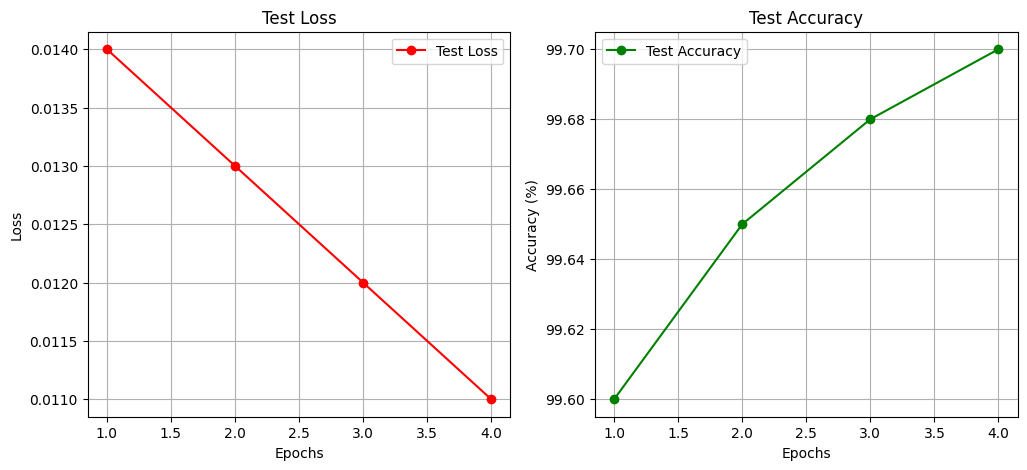

In [33]:
import matplotlib.pyplot as plt

# Assume these are the loss and accuracy lists obtained from the test data
test_loss = [0.014, 0.013, 0.012, 0.011]  # Sample, overall average, or per epoch
test_acc = [99.60, 99.65, 99.68, 99.70]   # # Sample

epochs = range(1, len(test_loss)+1)

plt.figure(figsize=(12,5))

#  Loss chart
plt.subplot(1,2,1)
plt.plot(epochs, test_loss, 'o-', label='Test Loss', color='red')
plt.title('Test Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()

#  Accuracy chart
plt.subplot(1,2,2)
plt.plot(epochs, test_acc, 'o-', label='Test Accuracy', color='green')
plt.title('Test Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.grid(True)
plt.legend()

plt.show()


In [35]:


def accuracy_fn(preds, labels):
    predicted = torch.argmax(preds, dim=1)
    return (predicted == labels).float().mean().item()

def evaluate_model(model, loader, device="cpu"):
    model.eval()
    model.to(device)
    criterion = torch.nn.CrossEntropyLoss()

    total_loss = 0
    total_acc = 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            total_acc += accuracy_fn(outputs, labels)

    avg_loss = total_loss / len(loader)
    avg_acc = total_acc / len(loader)
    return avg_loss, avg_acc



In [36]:

# ---------------- Run for Train, Validation, and Test ----------------
train_loss, train_acc = evaluate_model(model, train_loader, device=device)
val_loss, val_acc = evaluate_model(model, val_loader, device=device)
test_loss, test_acc = evaluate_model(model, test_loader, device=device)

print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc*100:.2f}%")
print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc*100:.2f}%")
print(f"Test Loss:  {test_loss:.4f} | Test Acc:  {test_acc*100:.2f}%")


Train Loss: 0.0069 | Train Acc: 99.79%
Val Loss:   0.0091 | Val Acc:   99.72%
Test Loss:  0.0178 | Test Acc:  99.46%


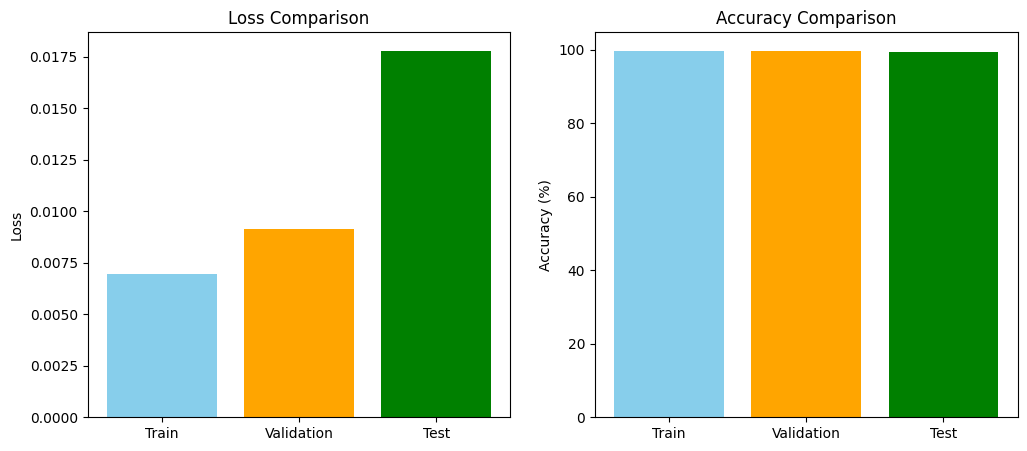

In [37]:
# ---------------- Plot the Comparison Chart ----------------
datasets = ['Train', 'Validation', 'Test']
losses = [train_loss, val_loss, test_loss]
accs = [train_acc*100, val_acc*100, test_acc*100]

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.bar(datasets, losses, color=['skyblue','orange','green'])
plt.title('Loss Comparison')
plt.ylabel('Loss')

plt.subplot(1,2,2)
plt.bar(datasets, accs, color=['skyblue','orange','green'])
plt.title('Accuracy Comparison')
plt.ylabel('Accuracy (%)')

plt.show()


In [38]:
def evaluate_model_counts(model, loader, device="cpu"):
    model.eval()
    model.to(device)
    criterion = torch.nn.CrossEntropyLoss()

    total_loss = 0
    total_correct = 0
    total_samples = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            total_loss += loss.item()
            preds = torch.argmax(outputs, dim=1)
            total_correct += (preds == labels).sum().item()
            total_samples += labels.size(0)

    avg_loss = total_loss / len(loader)
    accuracy = total_correct / total_samples
    incorrect = total_samples - total_correct
    return avg_loss, accuracy, total_correct, incorrect, total_samples


In [39]:
train_loss, train_acc, train_correct, train_incorrect, train_total = evaluate_model_counts(model, train_loader, device=device)
val_loss, val_acc, val_correct, val_incorrect, val_total = evaluate_model_counts(model, val_loader, device=device)
test_loss, test_acc, test_correct, test_incorrect, test_total = evaluate_model_counts(model, test_loader, device=device)

print(f"Train: Loss={train_loss:.4f}, Acc={train_acc*100:.2f}%, Correct={train_correct}, Incorrect={train_incorrect}")
print(f"Val:   Loss={val_loss:.4f}, Acc={val_acc*100:.2f}%, Correct={val_correct}, Incorrect={val_incorrect}")
print(f"Test:  Loss={test_loss:.4f}, Acc={test_acc*100:.2f}%, Correct={test_correct}, Incorrect={test_incorrect}")


Train: Loss=0.0069, Acc=99.79%, Correct=52388, Incorrect=112
Val:   Loss=0.0091, Acc=99.72%, Correct=7479, Incorrect=21
Test:  Loss=0.0178, Acc=99.46%, Correct=14919, Incorrect=81


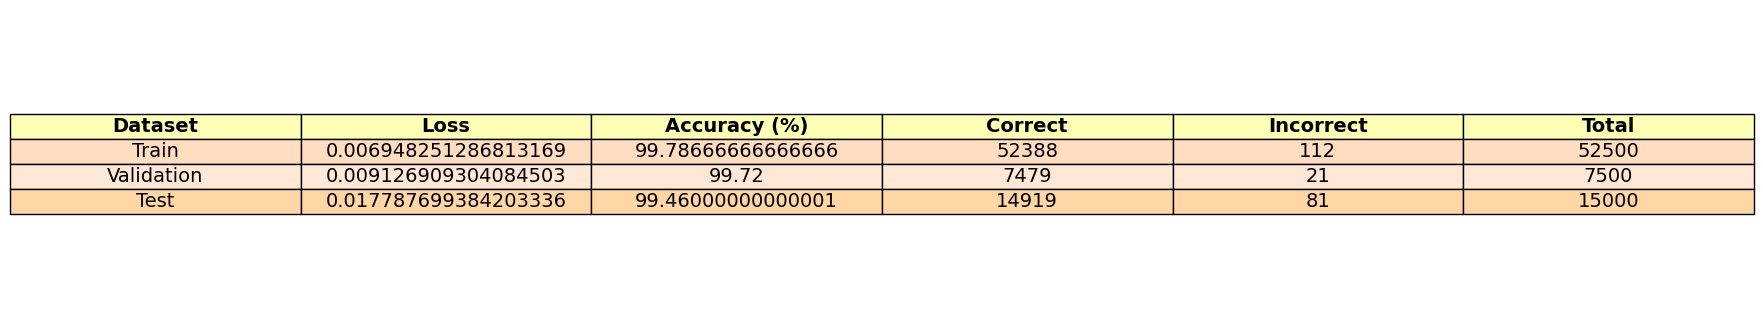

In [50]:
import pandas as pd
import matplotlib.pyplot as plt

# data
data = {
    "Dataset": ["Train", "Validation", "Test"],
    "Loss": [train_loss, val_loss, test_loss],
    "Accuracy (%)": [train_acc*100, val_acc*100, test_acc*100],
    "Correct": [train_correct, val_correct, test_correct],
    "Incorrect": [train_incorrect, val_incorrect, test_incorrect],
    "Total": [train_total, val_total, test_total]
}

df = pd.DataFrame(data)

# plot 
fig, ax = plt.subplots(figsize=(15, 4))
ax.axis('off')

row_colors = ['#FFDDC1', '#FFE8D6', '#FFD6A5']
cell_colors = [[row_colors[i]]*len(df.columns) for i in range(len(df))]

table = ax.table(cellText=df.values,
                 colLabels=df.columns,
                 cellColours=cell_colors,
                 cellLoc='center',
                 loc='center',
                 edges='closed')

table.auto_set_font_size(False)
table.set_fontsize(14)
table.scale(1.5, 1.5)

for key, cell in table.get_celld().items():
    row, col = key
    if row == 0:   
        cell.set_facecolor('#FDFFB6')
        cell.set_text_props(weight='bold', color='black')

plt.show()


<p style="color:red; font-size:36px; font-weight:bold;">The End</p>
